# Radioactive Decay

## Decay Statistics

In [1]:
import numpy as np

distance = 2 # mm
isotope = "Cs 137"

# Define data sets
counts_10s = np.array([11, 11, 7, 13, 12, 19, 6, 12, 9, 11, 8, 6, 11, 8, 10, 8, 8, 4, 9, 5, 11, 14, 10, 16, 10]) # add your data here
counts_5s = np.array([2, 0, 3, 7, 5, 2, 1, 7, 7, 0, 4,3,4,8,9,6,4,7,4,5,5,5,4,5,7,6,5,2,7,5,5,11,7,4,2,7,7,1,2,5,11,3,6,8,4,2,6,4,6,6
]) # add your data here

### Histograms

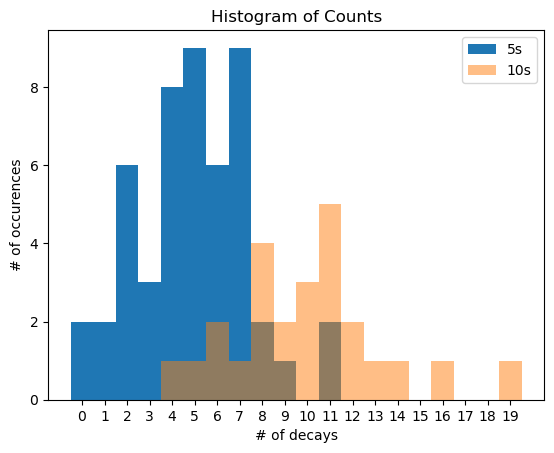

In [2]:
import matplotlib.pyplot as plt

# Determine the range of counts for the histogram
counts_max = int(max(max(counts_10s), max(counts_5s)))
counts_min = int(min(min(counts_10s), min(counts_5s)))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...

# Create the histogram
fig, ax = plt.subplots()
ax.set_xlabel('# of decays')
ax.set_ylabel('# of occurences')
ax.hist(counts_5s, bins=bins, align='left', label='5s')
ax.hist(counts_10s, bins=bins, align='left', label='10s', alpha=0.5)
ax.set_title('Histogram of Counts')
ax.set_xticks(range(counts_max+1))
ax.legend()
plt.show()


We can see a histogram of the counts of our two measurements. The x direction represents the amount of decays in the timeframe, and the y direction how many times that count occurred.

### Normal distribution
The normal distribution is a distribution for a real-valued random variable. It is bell-shaped, has a maximum and dropps off rather quickly in both directions. It usually arrives whenever you have a value with a random error or a random variable to begin with, like we do here. In general, it follows the equation $$\frac {1} {\sqrt{2 \pi \sigma}} e^{- \frac {(x-\mu)^2}{2 \sigma^2}}$$
with x being the random variable, $\sigma$ being the standard deviation and $\mu$ being the offset of the distributions center.

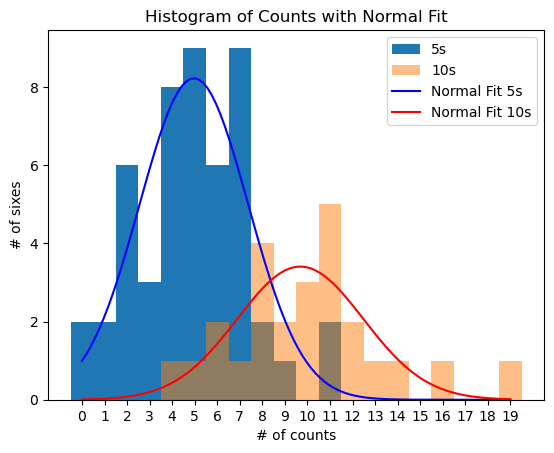

In [3]:
from scipy.optimize import curve_fit

# Define the normal distribution function
def normal_dist(x, A, mu, sigma):
    return A * (1/(sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

# Fit the normal distribution to the 10s data
x_10s = np.arange(counts_min, counts_max+1)
hist_10s, _ = np.histogram(counts_10s, bins=bins) # calculate the histogram for 10s data
# Use the histogram values as the y-data for fitting, add initial guesses for A, mu, sigma
popt_10s, _ = curve_fit(normal_dist, x_10s, hist_10s, 
                        p0=[np.max(hist_10s), np.mean(counts_10s), np.std(counts_10s)])

# Fit the normal distribution to the 5s data
x_5s = np.arange(counts_min, counts_max+1)
hist_5s, _ = np.histogram(counts_5s, bins=bins)
popt_5s, _ = curve_fit(normal_dist, x_5s, hist_5s, 
                       p0=[np.max(hist_5s), np.mean(counts_5s), np.std(counts_5s)])

# Plot the histograms and the fitted normal distributions
fig, ax = plt.subplots()
ax.set_xlabel('# of counts')
ax.set_ylabel('# of sixes')
ax.hist(counts_5s, bins=bins, align='left', label='5s')
ax.hist(counts_10s, bins=bins, align='left', label='10s', alpha=0.5)
x_fit = np.linspace(counts_min, counts_max, 100)
ax.plot(x_fit, normal_dist(x_fit, *popt_5s), 'b-', label='Normal Fit 5s')
ax.plot(x_fit, normal_dist(x_fit, *popt_10s), 'r-', label='Normal Fit 10s')
ax.set_title('Histogram of Counts with Normal Fit')
ax.set_xticks(range(counts_max+1))
ax.legend()

In [4]:
# Print the statistics and fit parameters
print(f"5s statistics: mean: {np.mean(counts_5s):.2f}, std: {np.std(counts_5s):.2f}")
print(f"5s fit parameters: µ={popt_5s[1]:.2f}, sigma={popt_5s[2]:.2f}")
print(f"10s statistics: mean: {np.mean(counts_10s):.2f}, std: {np.std(counts_10s):.2f}")
print(f"10s fit parameters: µ={popt_10s[1]:.2f}, sigma={popt_10s[2]:.2f}")

5s statistics: mean: 4.92, std: 2.46
5s fit parameters: µ=4.96, sigma=2.41
10s statistics: mean: 9.96, std: 3.32
10s fit parameters: µ=9.68, sigma=2.80


## Rolling Dice

### Binomial distribution
The binomial distribution represents the distribution of values from a boolean variable with a certain probability. It arises whenever one has independent yes-or-no events. For a binomial distribution with n trials and a success probability of p, the probability of k successes is described by the formula
$$\binom {n} {k} p^k (1-p)^{n-k}$$

### Histogram
A histogram shows the outcome of an experiment by partitioning the outcome space into discrete bins and showing how many times the expirments outcome fell into each of the bins. We show this for our dice experiment results, and overlay it with the expected binomial distribution for comparison.

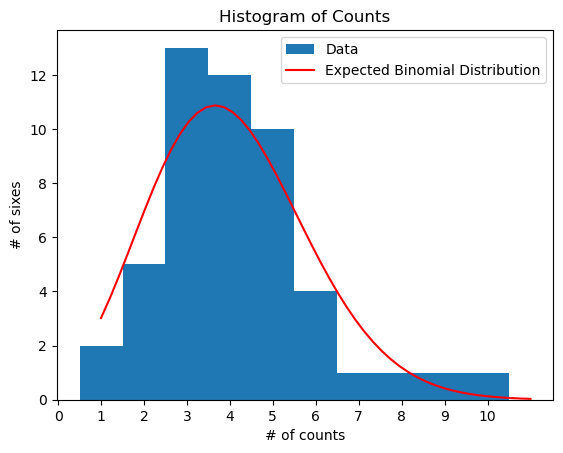

In [5]:
from scipy.special import comb


# data
counts = np.array([4, 3, 1, 4, 5, 5, 5, 3, 3, 5,
                     3, 5, 10, 2, 7, 5, 4, 5, 3, 1,
                     5, 6, 4, 3, 3, 8, 4, 6, 2, 4,
                     2, 6, 4, 5, 2, 2, 4, 3, 3, 9,
                     6, 4, 3, 3, 4, 4, 3, 3, 5, 4]) # add your data here
# alternatively generate array from csv file
# counts = np.genfromtxt('counts.csv', delimiter='c')


# Define the binomial distribution function
def binom(x, p, n):
    n_trials = len(counts)
    # n = 24

    return n_trials * comb(n, x) * p**x * (1-p)**(n-x)

# calculate plot range and bins for histogram
counts_max = int(max(counts))
counts_min = int(min(counts))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...

# calculate the binomial distribution for the given parameters
x = np.linspace(counts_min, counts_max+1)
p = 1/6
n_dice = 24

binom_values = binom(x, p, n_dice)

fig, ax = plt.subplots()
ax.set_xlabel('# of counts')
ax.set_ylabel('# of sixes')
ax.hist(counts, bins=bins, align='left', label='Data')
ax.plot(x, binom_values, 'r-', label='Expected Binomial Distribution')
ax.set_title('Histogram of Counts')
ax.set_xticks(range(counts_max+1))
plt.legend()
plt.show()


### Curve fit

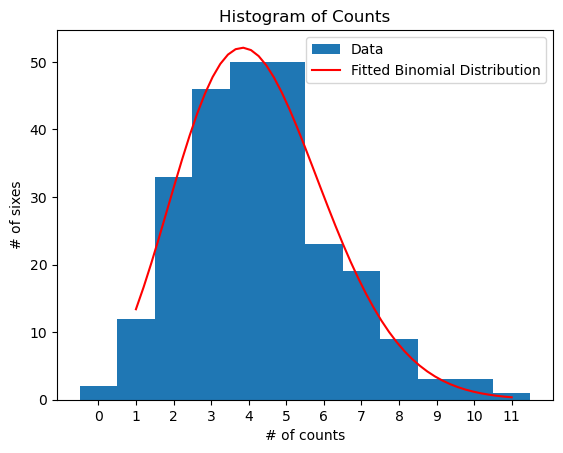

In [6]:
# combine data of all lab teams
rubas = np.array([4, 5, 3, 4, 6, 3, 8, 2, 3, 4,
                   0, 5, 4, 4, 5, 5, 5, 6, 8, 6, 
                   6, 4, 4, 7, 3, 3, 5, 3, 1, 5, 
                   8, 7, 5, 2, 7, 6, 3, 1, 6, 5, 
                   3, 7, 7, 5, 2, 3, 2, 3, 2, 4, 11])
Albissa = np.array([3, 3, 4, 5, 4, 5, 5, 6, 1, 5, 
                     8, 3, 3, 1, 8, 4, 5, 7, 4, 5, 
                     4, 5, 5, 7, 5, 4, 6, 4, 5, 4, 
                     2, 5, 2, 2, 5, 7, 2, 5, 5, 3, 
                     4, 4, 2, 3, 8, 5, 3, 3, 5, 5])
Dandrey = np.array([2, 7, 4, 3, 3, 2, 7, 4, 3, 7, 
                     4, 1, 2, 3, 5, 3, 5, 2, 4, 2,
                     6, 2, 5, 2, 7, 7, 5, 3, 3, 3, 
                     1, 6, 8, 7, 2, 10, 4, 2, 9, 2, 
                     7, 4, 5, 5, 3, 6, 2, 2, 4, 5])
Raphael = np.array([4, 5, 3, 6, 7, 4, 6, 4, 4, 1,
                    4, 5, 4, 7, 2, 6, 4, 4, 4, 4,
                    4, 2, 0, 3, 6])
Yvonne = np.array([3, 6, 2, 7, 2, 5, 5, 8, 5, 4,
                5, 3, 2, 4, 3, 1, 1, 6, 6, 3,
                10, 1, 9, 2, 6])
counts_all = np.concatenate((counts, rubas, Albissa, Dandrey, Raphael, Yvonne))

def binom(x, p, n):
    n_trials = len(counts_all) # use correct n_trials

    return n_trials * comb(n, x) * p**x * (1-p)**(n-x)

# calculate plot range and bins for histogram
counts_max = int(max(counts_all))
counts_min = int(min(counts_all))
bins = range(counts_min, counts_max+2) # bins: [0, 1), [1, 2), ...


hist, bin_edges = np.histogram(counts_all, bins)
coeff, pcov = curve_fit(binom, bin_edges[:-1], hist, p0=[p, n_dice])
p_fit, n_fit = coeff

binom_fit = binom(x, p_fit, n_fit)

# Plot the histogram and the fitted binomial distribution
fig, ax = plt.subplots()
ax.set_xlabel('# of counts')
ax.set_ylabel('# of sixes')
ax.hist(counts_all, bins=bins, align='left', label='Data')
ax.plot(x, binom_fit, 'r-', label='Fitted Binomial Distribution')
ax.set_title('Histogram of Counts')
ax.set_xticks(range(counts_max+1))
plt.legend()
plt.show()


In [7]:
# compare the fit parameters to the expected values
print(f"p_fit: {p_fit:.4f}, expected p: {1/6:.4f}, error: {100*(p_fit/(1/6)-1):.2f}%")
print(f"n_fit: {n_fit:.4f}, expected n: 24, error: +{100*(n_fit/24 -1):.2f}%")
print(f"n_fit * p_fit: {n_fit * p_fit:.4f}, expected n*p: {24/6:.4f}, error: {100*(n_fit * p_fit/(24/6)-1):.3f}%")

p_fit: 0.1257, expected p: 0.1667, error: -24.55%
n_fit: 33.5133, expected n: 24, error: +39.64%
n_fit * p_fit: 4.2142, expected n*p: 4.0000, error: 5.356%


#### Discussion
These fitted results are significantly off. While this is very suprising for an experiment as basic as rolling dice, it is most likely best explained by a combination of two factors. We firstly have a relatively large amount of outliers, e.g. the 11/24 sixes, which leads to a higher-than-expected variance. Secondly, we let both n and p parameter be freely fitted, and the optimizer thus increases the number of trials, balancing to keep the same mean, to explain the high variance.

# Aditional Tasks
## 1

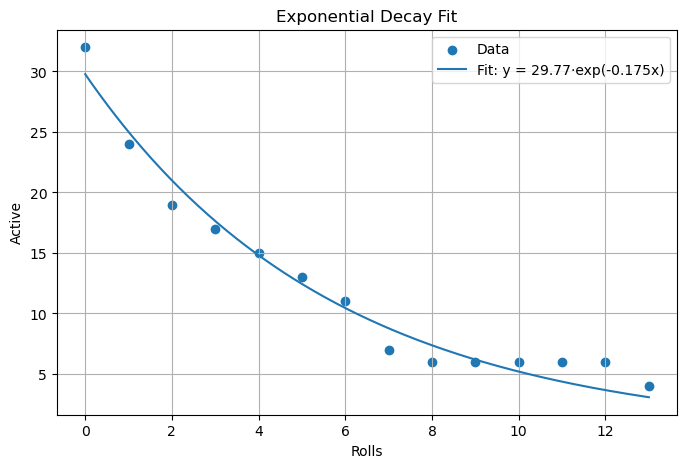

A = 29.771
k = 0.175


In [8]:
#Additional task:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
rolls = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13])
actif = np.array([32,24,19,17,15,13,11,7,6,6,6,6,6,4])

# Exponential decay function
def exp_decay(x, A, k):
    return A * np.exp(-k * x)

# Fit
params, covariance = curve_fit(exp_decay, rolls, actif)

A_fit, k_fit = params

# Smooth x values for plotting
x_fit = np.linspace(min(rolls), max(rolls), 300)
y_fit = exp_decay(x_fit, A_fit, k_fit)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(rolls, actif, label="Data")
plt.plot(
    x_fit,
    y_fit,
    label=f"Fit: y = {A_fit:.2f}·exp(-{k_fit:.3f}x)"
)

plt.xlabel("Rolls")
plt.ylabel("Active")
plt.title("Exponential Decay Fit")
plt.grid()
plt.legend()

plt.show()

# Print parameters
print(f"A = {A_fit:.3f}")
print(f"k = {k_fit:.3f}")

We roll 32 dice and remove the ones which show a six. If we graph the active (remaining) dice to the number of rolls we get this curve. The half life we get is k=0.175. This is pretty close to the expected value of 0.167 (the probability of rolling a 6). The more dice you start with, the closer the half life will be to the expected value.
